<a href="https://colab.research.google.com/github/MahdiMashayekhi-AI/Machine-Learning-Projects/blob/main/02-supervised-learning/02-regression/Car-Price-Prediction/Car_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install category_encoders

In [79]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from category_encoders import TargetEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import KNNImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
import warnings

warnings.filterwarnings('ignore')

pd.options.display.float_format = '{:.2f}'.format

print("Libraries imported successfully, warnings ignored, and pandas display options set.")

Libraries imported successfully, warnings ignored, and pandas display options set.


In [3]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "car_price_prediction.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "deepcontractor/car-price-prediction-challenge",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

First 5 records:          ID  Price  Levy Manufacturer    Model  Prod. year   Category  \
0  45654403  13328  1399        LEXUS   RX 450        2010       Jeep   
1  44731507  16621  1018    CHEVROLET  Equinox        2011       Jeep   
2  45774419   8467     -        HONDA      FIT        2006  Hatchback   
3  45769185   3607   862         FORD   Escape        2011       Jeep   
4  45809263  11726   446        HONDA      FIT        2014  Hatchback   

  Leather interior Fuel type Engine volume    Mileage  Cylinders  \
0              Yes    Hybrid           3.5  186005 km       6.00   
1               No    Petrol             3  192000 km       6.00   
2               No    Petrol           1.3  200000 km       4.00   
3              Yes    Hybrid           2.5  168966 km       4.00   
4              Yes    Petrol           1.3   91901 km       4.00   

  Gear box type Drive wheels   Doors             Wheel   Color  Airbags  
0     Automatic          4x4  04-May        Left wheel  Silve

In [4]:
df.head()

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.00,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.00,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.00,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.00,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.00,Automatic,Front,04-May,Left wheel,Silver,4


## Display basic info

### Subtask:
Show the first few rows, data types, and non-null counts of the dataframe.


**Reasoning**:
Display the first few rows and the data types and non-null counts of the dataframe as requested by the subtask.



In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19237 entries, 0 to 19236
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                19237 non-null  int64  
 1   Price             19237 non-null  int64  
 2   Levy              19237 non-null  object 
 3   Manufacturer      19237 non-null  object 
 4   Model             19237 non-null  object 
 5   Prod. year        19237 non-null  int64  
 6   Category          19237 non-null  object 
 7   Leather interior  19237 non-null  object 
 8   Fuel type         19237 non-null  object 
 9   Engine volume     19237 non-null  object 
 10  Mileage           19237 non-null  object 
 11  Cylinders         19237 non-null  float64
 12  Gear box type     19237 non-null  object 
 13  Drive wheels      19237 non-null  object 
 14  Doors             19237 non-null  object 
 15  Wheel             19237 non-null  object 
 16  Color             19237 non-null  object

In [6]:
print(f"Number of rows in dataset: {df.shape[0]}")
print(f"Number of cols in dataset: {df.shape[1]}")

Number of rows in dataset: 19237
Number of cols in dataset: 18


In [7]:
df.dtypes

,0
ID,int64
Price,int64
Levy,object
Manufacturer,object
Model,object
Prod. year,int64
Category,object
Leather interior,object
Fuel type,object
Engine volume,object


In [8]:
numerical_cols = df.select_dtypes(include=np.number)
numerical_cols.describe()

,ID,Price,Prod. year,Cylinders,Airbags
count,19237.00,19237.00,19237.00,19237.00,19237.00
mean,45576535.89,18555.93,2010.91,4.58,6.58
std,936591.42,190581.27,5.67,1.20,4.32
min,20746880.00,1.00,1939.00,1.00,0.00
25%,45698374.00,5331.00,2009.00,4.00,4.00
50%,45772308.00,13172.00,2012.00,4.00,6.00
75%,45802036.00,22075.00,2015.00,4.00,12.00
max,45816654.00,26307500.00,2020.00,16.00,16.00


In [9]:
categorical_cols = df.select_dtypes(include=['object', 'category'])
display(categorical_cols.describe())

for col in categorical_cols.columns:
    print(f"Value counts for {col}:")
    print(categorical_cols[col].value_counts())
    print("\n")

,Levy,Manufacturer,Model,Category,Leather interior,Fuel type,Engine volume,Mileage,Gear box type,Drive wheels,Doors,Wheel,Color
count,19237,19237,19237,19237,19237,19237,19237,19237,19237,19237,19237,19237,19237
unique,559,65,1590,11,2,7,107,7687,4,3,3,2,16
top,-,HYUNDAI,Prius,Sedan,Yes,Petrol,2,0 km,Automatic,Front,04-May,Left wheel,Black
freq,5819,3769,1083,8736,13954,10150,3916,721,13514,12874,18332,17753,5033


Value counts for Levy:
Levy
-       5819
765      486
891      461
639      410
640      405
        ... 
2308       1
4860       1
1641       1
1045       1
5681       1
Name: count, Length: 559, dtype: int64


Value counts for Manufacturer:
Manufacturer
HYUNDAI          3769
TOYOTA           3662
MERCEDES-BENZ    2076
FORD             1111
CHEVROLET        1069
                 ... 
LAMBORGHINI         1
PONTIAC             1
SATURN              1
ASTON MARTIN        1
GREATWALL           1
Name: count, Length: 65, dtype: int64


Value counts for Model:
Model
Prius              1083
Sonata             1079
Camry               938
Elantra             922
E 350               542
                   ... 
530 i                 1
E 500 AVG             1
Vito Extralong        1
C 240 W 203           1
Vito Exstralong       1
Name: count, Length: 1590, dtype: int64


Value counts for Category:
Category
Sedan          8736
Jeep           5473
Hatchback      2847
Minivan         647
Coupe     

In [10]:
df.isnull().sum()

,0
ID,0
Price,0
Levy,0
Manufacturer,0
Model,0
Prod. year,0
Category,0
Leather interior,0
Fuel type,0
Engine volume,0


In [11]:
print(f"Total number of NaN values in dataset: {df.isnull().sum().sum()}")

Total number of NaN values in dataset: 0


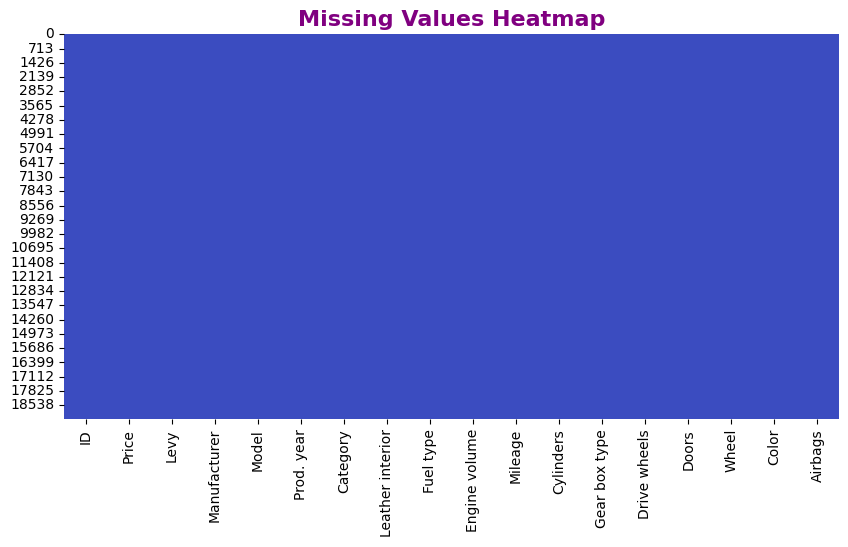

In [12]:
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cmap='coolwarm', cbar=False)
plt.title("Missing Values Heatmap", fontsize=16, fontweight='bold', color='purple')
plt.show()

In [13]:
print(f"Number of duplicate value in dataset: {df.duplicated().sum()}")

Number of duplicate value in dataset: 313


In [14]:
corr_matrix = df.select_dtypes(include=['number']).corr()
corr_matrix

,ID,Price,Prod. year,Cylinders,Airbags
ID,1.00,-0.00,0.07,-0.04,-0.02
Price,-0.00,1.00,0.01,0.01,-0.01
Prod. year,0.07,0.01,1.00,-0.10,0.24
Cylinders,-0.04,0.01,-0.10,1.00,0.18
Airbags,-0.02,-0.01,0.24,0.18,1.00


In [15]:
corr_matrix['Price'].sort_values(ascending=False)

,Price
Price,1.00
Prod. year,0.01
Cylinders,0.01
ID,-0.00
Airbags,-0.01


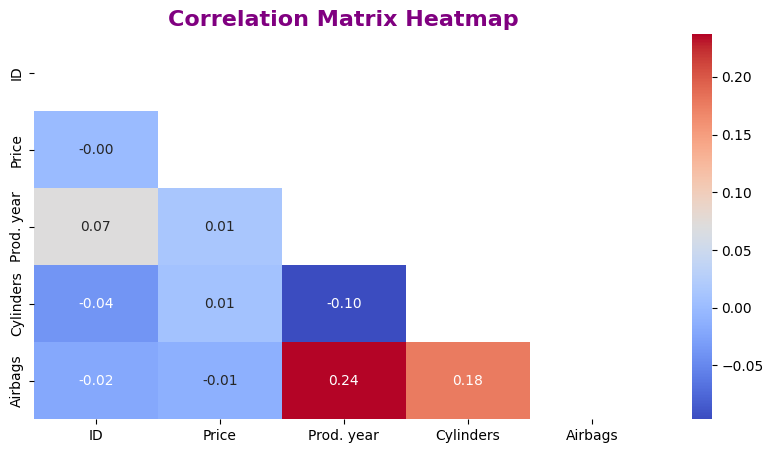

In [16]:
plt.figure(figsize=(10, 5))
mask = np.triu(np.ones_like(corr_matrix))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Correlation Matrix Heatmap", fontsize=16, fontweight='bold', color='purple')
plt.show()

In [17]:
def plot_hist_kde_box(column_name, data=df):
  plt.figure(figsize=(15, 5))

  # Plot Histogram
  plt.subplot(1, 3, 1)
  sns.histplot(data[column_name], kde=True, color='b')
  plt.title(f"{column_name.capitalize()} Distribution", fontsize=16, fontweight='bold', color='purple')
  plt.xlabel(column_name.capitalize(), fontsize=14)
  plt.ylabel("Frequency", fontsize=14)

  # Plot KDE
  plt.subplot(1, 3, 2)
  sns.kdeplot(data=data, x=column_name, fill=True, color='r')
  plt.title(f"Kernel Density Estimate of {column_name.capitalize()}", fontsize=16, fontweight='bold', color='purple')
  plt.xlabel(column_name.capitalize(), fontsize=14)
  plt.ylabel("Density", fontsize=14)
  plt.xlim(data[column_name].min(), data[column_name].max())

  # Plot Box Plot
  plt.subplot(1, 3, 3)
  sns.boxplot(y=data[column_name], color='g')
  plt.title(f"Box Plot of {column_name.capitalize()}", fontsize=16, fontweight='bold', color='purple')
  plt.xlabel(column_name.capitalize(), fontsize=14)

  plt.tight_layout()
  plt.show()

In [18]:
filter_df = df[(df['Price'] > 1000) & (df['Price'] < 50000)]

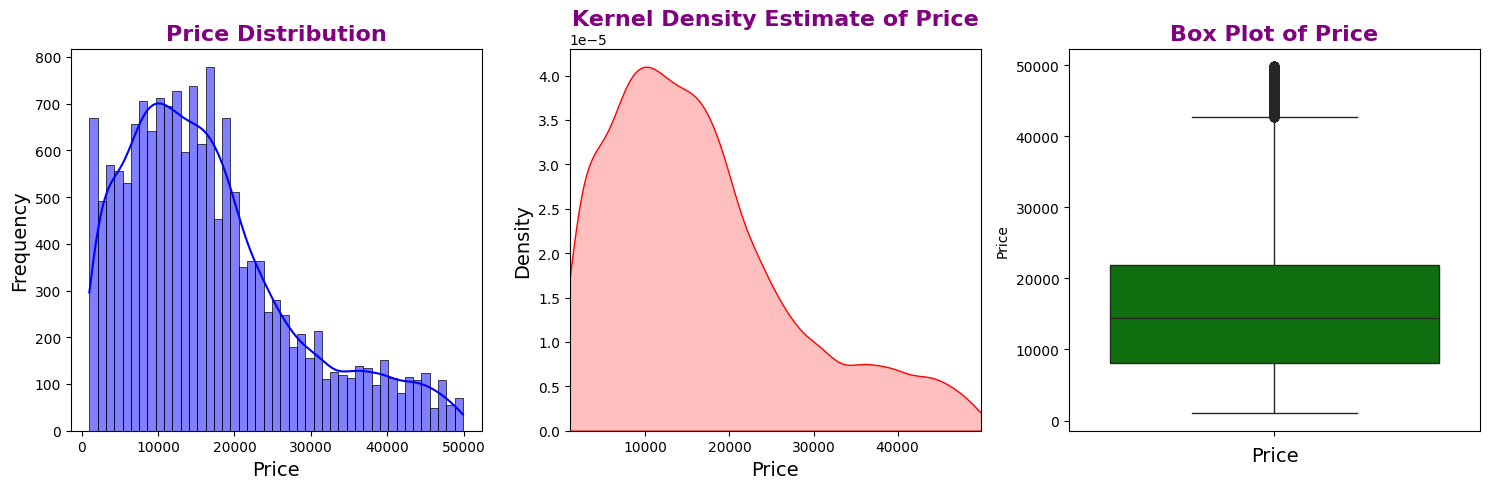

In [19]:
plot_hist_kde_box('Price', data=filter_df)

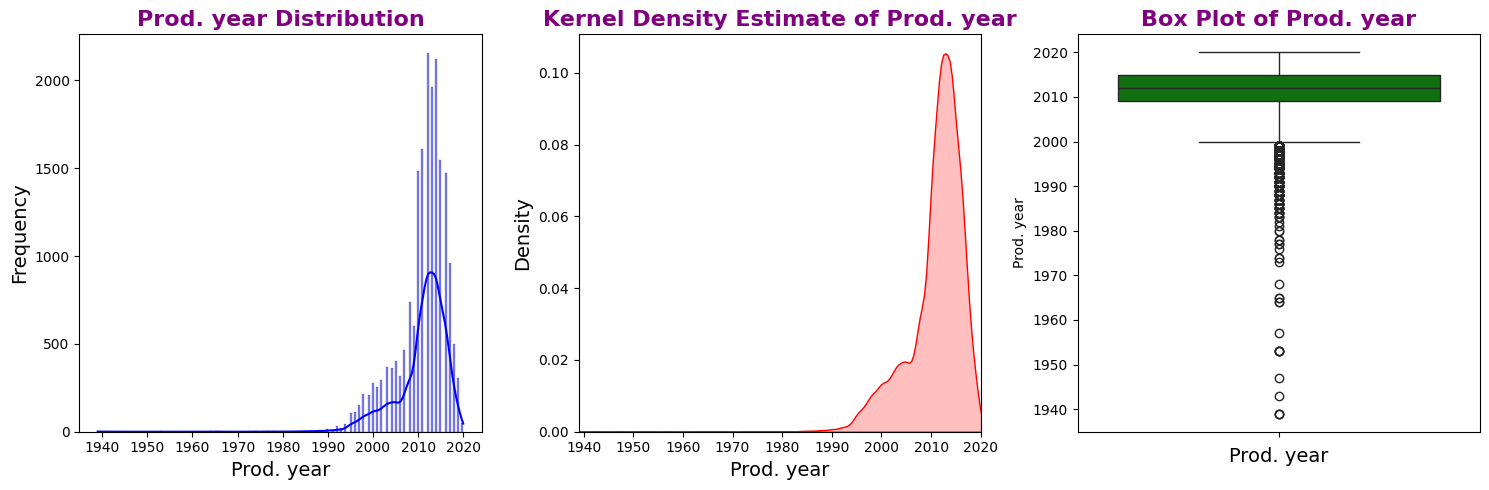

In [20]:
plot_hist_kde_box('Prod. year')

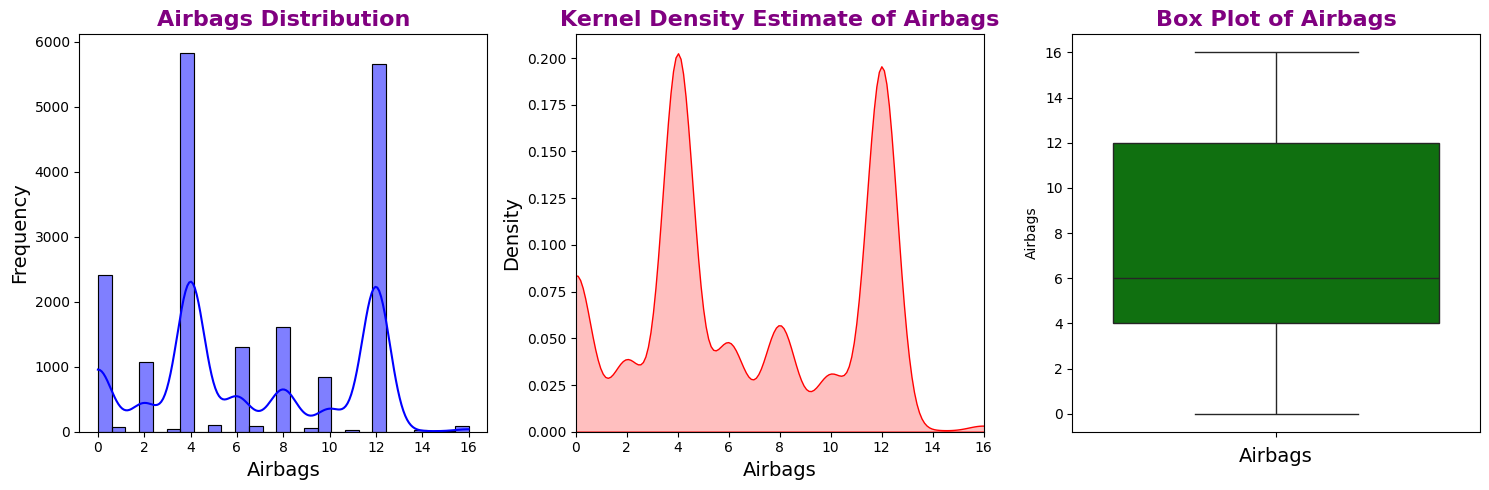

In [21]:
plot_hist_kde_box('Airbags')

In [22]:
def plot_pie_count(column_name, data=df):
    plt.figure(figsize=(15, 5))

    # Pie Plot
    plt.subplot(1, 2, 1)
    data[column_name].value_counts().plot.pie(autopct='%1.1f%%', startangle=90)
    plt.title(f'Distribution of {column_name.capitalize()}', fontsize=16, fontweight='bold', color='purple')
    plt.ylabel('')

    # Count Plot
    plt.subplot(1, 2, 2)
    sns.countplot(x=column_name, data=data, palette='viridis')
    plt.title(f'Count of {column_name.capitalize()}', fontsize=16, fontweight='bold', color='purple')
    plt.xlabel(column_name.capitalize(), fontsize=14)
    plt.ylabel("Count", fontsize=14)
    plt.tight_layout()
    plt.show()

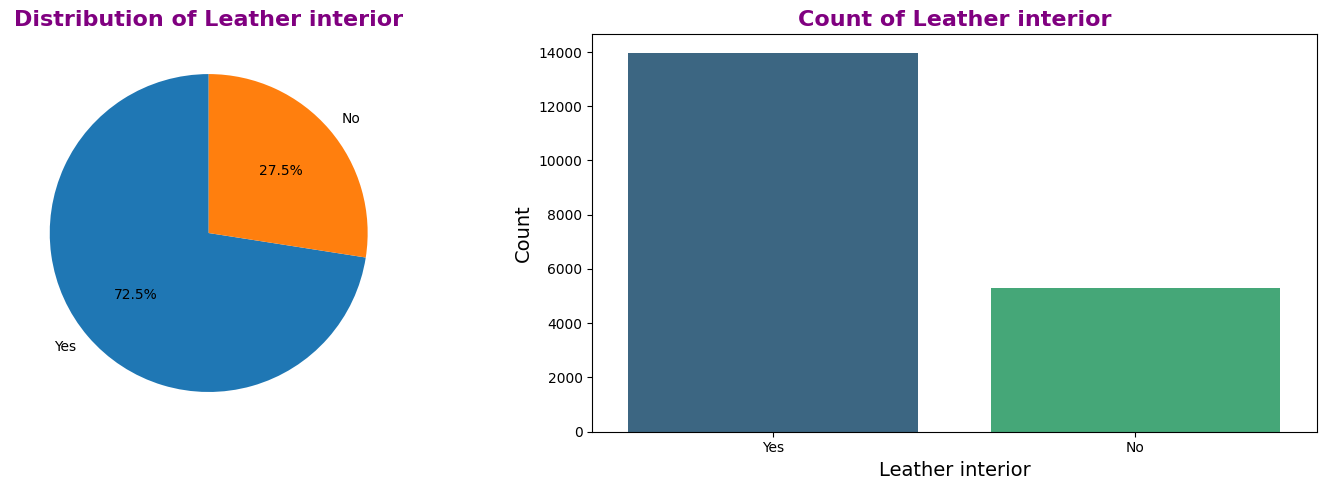

In [23]:
plot_pie_count('Leather interior')

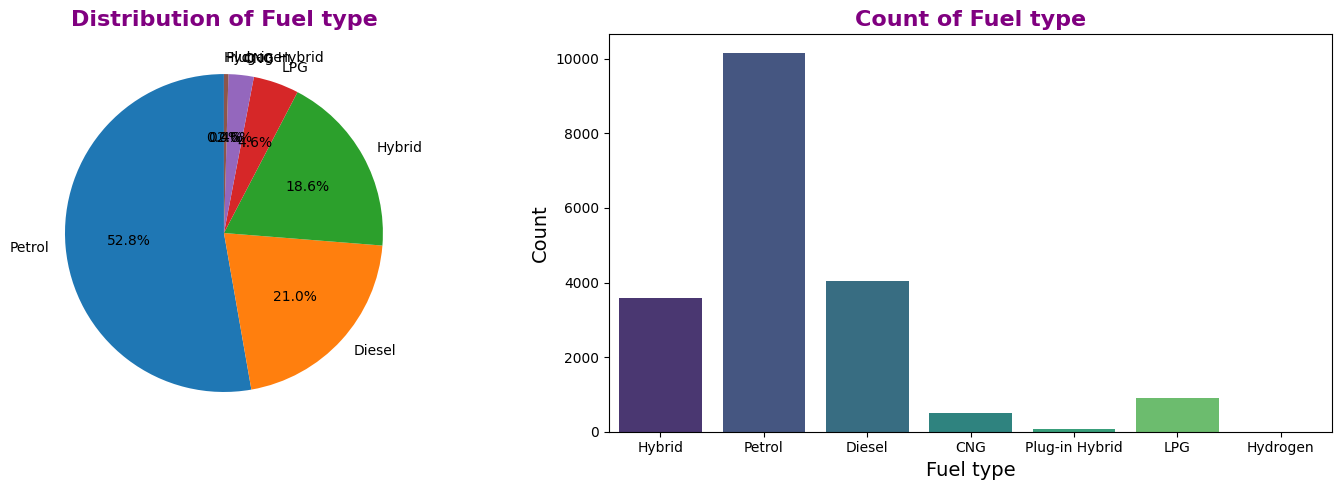

In [24]:
plot_pie_count('Fuel type')

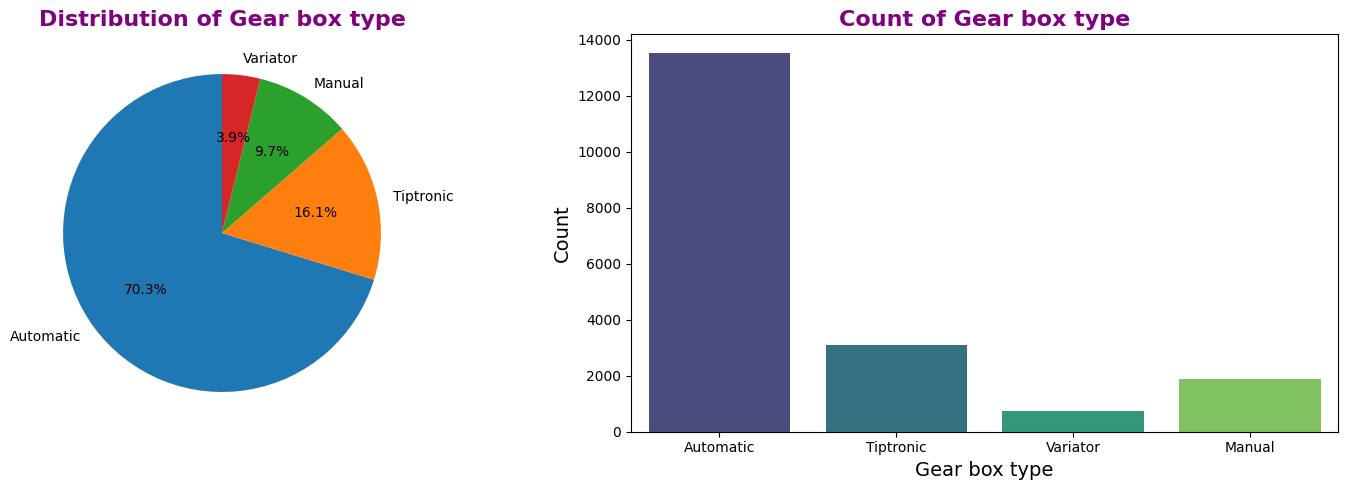

In [25]:
plot_pie_count('Gear box type')

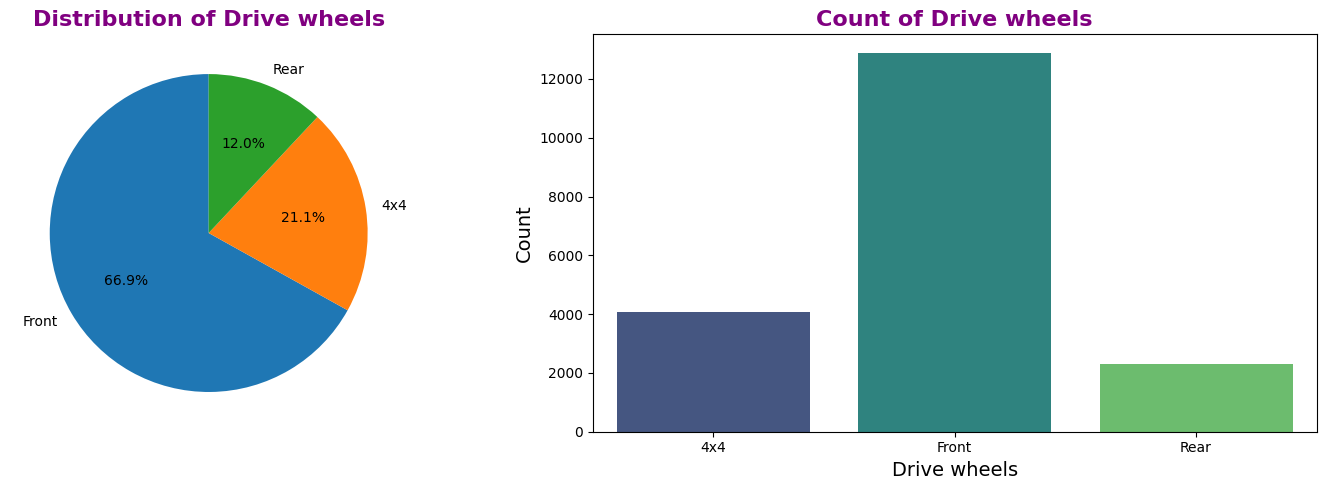

In [26]:
plot_pie_count('Drive wheels')

In [27]:
def plot_scatter(column_name, data=df, target='Price'):
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=data, x=column_name, y=target)
    plt.title(f'Scatter Plot of {column_name.capitalize()} vs {target.capitalize()}', fontsize=16, fontweight='bold', color='purple')
    plt.xlabel(column_name.capitalize(), fontsize=14)
    plt.ylabel(target.capitalize(), fontsize=14)
    plt.grid(True)
    plt.show()

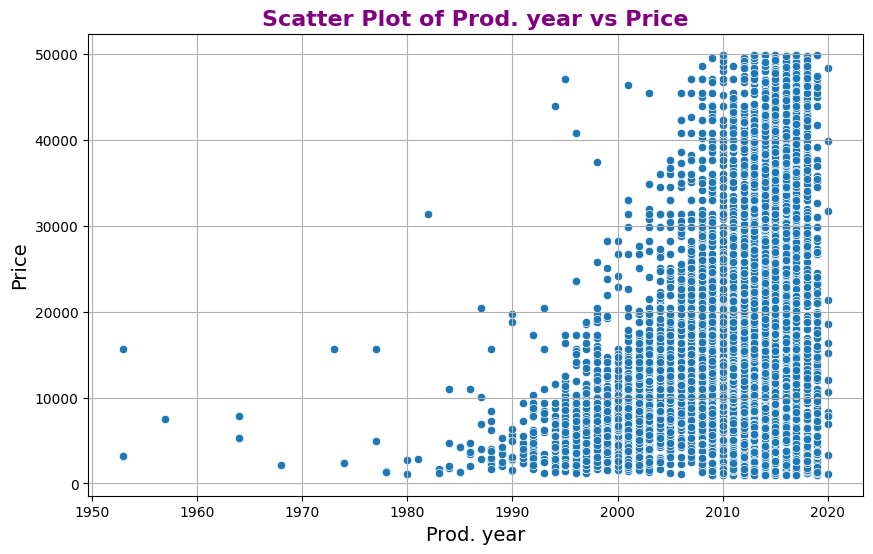

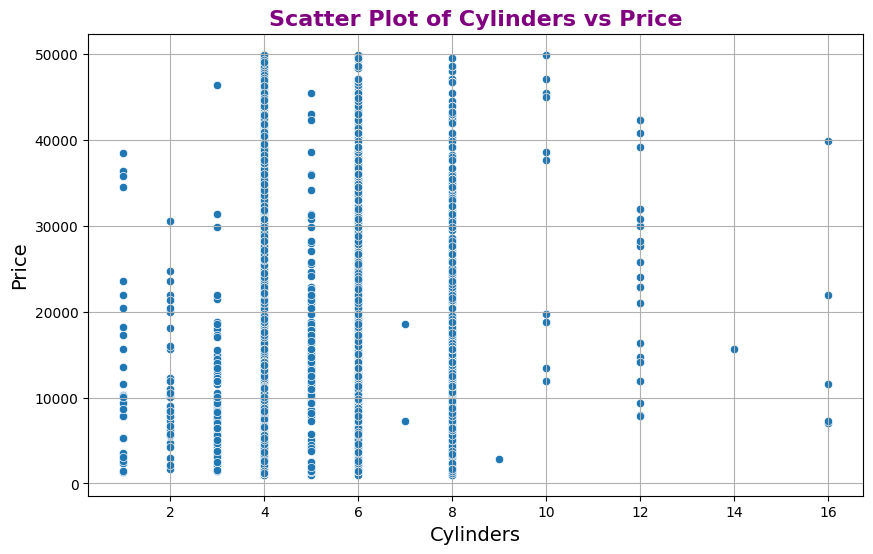

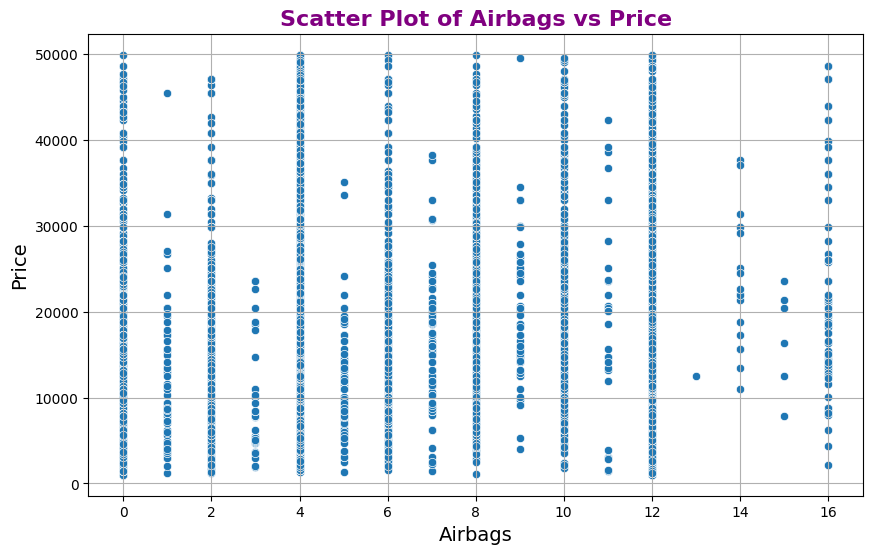

In [28]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

cols_to_plot = [col for col in numerical_cols if col not in ['Price', 'ID']]

for col in cols_to_plot:
    plot_scatter(col, filter_df)

## Data Preprocessing

In [29]:
# Remove unnecessary columns
df.drop(['ID'], axis=1, inplace=True)

In [30]:
# Define logical bounds for price
min_price = 1000
max_price = 100000

# Create boolean mask
mask = (df['Price'] >= min_price) & (df['Price'] <= max_price)

# Count rows
total_rows = len(df)
valid_rows = mask.sum()
invalid_rows = total_rows - valid_rows
invalid_percent = 100 * invalid_rows / total_rows

# Print stats
print(f"🔹 Total rows: {total_rows}")
print(f"✅ Valid price rows: {valid_rows}")
print(f"❌ Invalid price rows: {invalid_rows}")
print(f"📉 Percentage of rows to be removed: {invalid_percent:.2f}%")

# Filter the dataset
df_clean = df[mask].copy()

🔹 Total rows: 19237
✅ Valid price rows: 16550
❌ Invalid price rows: 2687
📉 Percentage of rows to be removed: 13.97%


In [31]:
df_clean['Price'].describe()

,Price
count,16550.00
mean,18908.81
std,15212.95
min,1000.00
25%,8467.00
50%,15060.00
75%,23834.00
max,99440.00


In [32]:
# Convert object columns like Levy, Engine volume, Mileage to numerical

df_clean['Levy'] = pd.to_numeric(df_clean['Levy'], errors='coerce')
df_clean['Engine volume'] = pd.to_numeric(df_clean['Engine volume'], errors='coerce').astype(float)
df_clean['Mileage'] = df_clean['Mileage'].str.replace('km', '').str.strip().astype(float)

In [33]:
df_clean.head()

,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,13328,1399.00,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.50,186005.00,6.00,Automatic,4x4,04-May,Left wheel,Silver,12
1,16621,1018.00,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3.00,192000.00,6.00,Tiptronic,4x4,04-May,Left wheel,Black,8
2,8467,NaN,HONDA,FIT,2006,Hatchback,No,Petrol,1.30,200000.00,4.00,Variator,Front,04-May,Right-hand drive,Black,2
3,3607,862.00,FORD,Escape,2011,Jeep,Yes,Hybrid,2.50,168966.00,4.00,Automatic,4x4,04-May,Left wheel,White,0
4,11726,446.00,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.30,91901.00,4.00,Automatic,Front,04-May,Left wheel,Silver,4


In [34]:
df_clean.dtypes

,0
Price,int64
Levy,float64
Manufacturer,object
Model,object
Prod. year,int64
Category,object
Leather interior,object
Fuel type,object
Engine volume,float64
Mileage,float64


In [35]:
df_clean.isnull().sum()

,0
Price,0
Levy,5383
Manufacturer,0
Model,0
Prod. year,0
Category,0
Leather interior,0
Fuel type,0
Engine volume,1835
Mileage,0


In [36]:
# Spliting the dataset
X = df_clean.drop('Price', axis=1)
y = df_clean['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [37]:
# Feature Encoding
def merge_rare_categories(series, threshold=100):
    value_counts = series.value_counts()
    rare = value_counts[value_counts < threshold].index
    return series.apply(lambda x: 'Other' if x in rare else x)

for col in ['Manufacturer', 'Model']:
    X_train[col] = merge_rare_categories(X_train[col])
    X_test[col] = merge_rare_categories(X_test[col])

In [38]:
target_encoder = TargetEncoder(cols=['Manufacturer', 'Model'])
X_train[['Manufacturer', 'Model']] = target_encoder.fit_transform(
    X_train[['Manufacturer', 'Model']], y_train
)
X_test[['Manufacturer', 'Model']] = target_encoder.transform(
    X_test[['Manufacturer', 'Model']]
)

In [39]:
for col in ['Category', 'Color']:
    freq_map = X_train[col].value_counts(normalize=True)
    X_train[col] = X_train[col].map(freq_map)
    X_test[col] = X_test[col].map(freq_map)
    # For unseen categories in test
    X_test[col].fillna(0, inplace=True)

In [40]:
binary_cols = ['Leather interior', 'Wheel']
for col in binary_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])

In [41]:
door_map = {
    '02-Mar': 2,
    '04-May': 4,
    '>5': 5
}
X_train['Doors'] = X_train['Doors'].map(door_map)
X_test['Doors'] = X_test['Doors'].map(door_map)

In [48]:
onehot_cols = ['Fuel type', 'Gear box type', 'Drive wheels']
ohe = OneHotEncoder(drop='first', handle_unknown='ignore')

ohe_train = ohe.fit_transform(X_train[onehot_cols]).toarray()
ohe_test = ohe.transform(X_test[onehot_cols]).toarray()

ohe_columns = ohe.get_feature_names_out(onehot_cols)
X_train_ohe = pd.DataFrame(ohe_train, columns=ohe_columns, index=X_train.index)
X_test_ohe = pd.DataFrame(ohe_test, columns=ohe_columns, index=X_test.index)

X_train = pd.concat([X_train.drop(onehot_cols, axis=1), X_train_ohe], axis=1)
X_test = pd.concat([X_test.drop(onehot_cols, axis=1), X_test_ohe], axis=1)

In [51]:
X_train.head()

,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Engine volume,Mileage,Cylinders,Doors,...,Fuel type_Hybrid,Fuel type_Hydrogen,Fuel type_LPG,Fuel type_Petrol,Fuel type_Plug-in Hybrid,Gear box type_Manual,Gear box type_Tiptronic,Gear box type_Variator,Drive wheels_Front,Drive wheels_Rear
11544,779.00,17212.39,16123.83,2013,0.46,1,2.50,166720.00,4.00,4,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00
5844,1363.00,26670.21,42657.34,2012,0.27,1,4.60,255406.00,8.00,4,...,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00
4001,NaN,12820.34,13279.45,2016,0.46,1,NaN,32000.00,4.00,4,...,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00
17518,694.00,19751.06,17397.80,2014,0.02,0,2.20,160000.00,5.00,4,...,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00
12247,NaN,17212.39,17397.80,2003,0.04,0,2.00,195000.00,4.00,4,...,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00


In [52]:
X_train.dtypes

,0
Levy,float64
Manufacturer,float64
Model,float64
Prod. year,int64
Category,float64
Leather interior,int64
Engine volume,float64
Mileage,float64
Cylinders,float64
Doors,int64


In [56]:
# Handle missing values
knn_imputer = KNNImputer(n_neighbors=5)
X_train = pd.DataFrame(knn_imputer.fit_transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(knn_imputer.transform(X_test), columns=X_test.columns)

In [58]:
# Feature Scaling with RobustScaler
scaler = RobustScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

In [59]:
X_train.head()

,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Engine volume,Mileage,Cylinders,Doors,...,Fuel type_Hybrid,Fuel type_Hydrogen,Fuel type_LPG,Fuel type_Petrol,Fuel type_Plug-in Hybrid,Gear box type_Manual,Gear box type_Tiptronic,Gear box type_Variator,Drive wheels_Front,Drive wheels_Rear
0,-0.14,0.00,-1.00,0.17,0.59,0.00,0.71,0.38,0.00,0.00,...,1.00,0.00,0.00,-1.00,0.00,0.00,0.00,0.00,0.00,0.00
1,1.41,1.37,19.83,0.00,0.00,0.00,3.71,1.17,4.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-1.00,0.00
2,0.33,-0.64,-3.23,0.67,0.59,0.00,0.00,-0.82,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
3,-0.36,0.37,0.00,0.33,-0.82,-1.00,0.29,0.32,1.00,0.00,...,0.00,0.00,0.00,-1.00,0.00,1.00,0.00,0.00,-1.00,1.00
4,0.02,0.00,0.00,-1.50,-0.76,-1.00,0.00,0.63,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


## Training the models

In [70]:
def evaluate_model(y_true, y_pred, model_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print(f"Metrics for {model_name}:")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R-squared (R2): {r2 * 100:.4f}%")
    print("\n")

    return mse, rmse, r2

In [74]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Lasso Regression': Lasso(),
    'Elastic Net Regression': ElasticNet(),
    'Decision Tree Regression': DecisionTreeRegressor(random_state=42),
    'Random Forest Regression': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting Regression': GradientBoostingRegressor(),
    'Support Vector Regression': SVR(),
    'K-Nearest Neighbors Regression': KNeighborsRegressor(n_neighbors=5),
    'XGBoost Regression': XGBRegressor(random_state=42)
}

model_results_list = []

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse, rmse, r2 =  evaluate_model(y_test, y_pred, name)
    model_results_list.append([name, mse, rmse, r2])

Training Linear Regression...
Metrics for Linear Regression:
MSE: 157387147.2043
RMSE: 12545.4034
R-squared (R2): 32.6319%


Training Ridge Regression...
Metrics for Ridge Regression:
MSE: 157390196.3720
RMSE: 12545.5250
R-squared (R2): 32.6306%


Training Lasso Regression...
Metrics for Lasso Regression:
MSE: 157404284.4378
RMSE: 12546.0864
R-squared (R2): 32.6245%


Training Elastic Net Regression...
Metrics for Elastic Net Regression:
MSE: 182103987.3162
RMSE: 13494.5910
R-squared (R2): 22.0521%


Training Decision Tree Regression...
Metrics for Decision Tree Regression:
MSE: 109103589.0714
RMSE: 10445.2663
R-squared (R2): 53.2992%


Training Random Forest Regression...
Metrics for Random Forest Regression:
MSE: 64222129.9889
RMSE: 8013.8711
R-squared (R2): 72.5103%


Training Gradient Boosting Regression...
Metrics for Gradient Boosting Regression:
MSE: 102151884.4714
RMSE: 10107.0215
R-squared (R2): 56.2748%


Training Support Vector Regression...
Metrics for Support Vector Regres

In [78]:
result_df = pd.DataFrame(model_results_list, columns=['Model', 'MSE', 'RMSE', 'R2'])
result_df.sort_values(by='R2', ascending=False)

,Model,MSE,RMSE,R2
9,XGBoost Regression,63325940.00,7957.76,0.73
5,Random Forest Regression,64222129.99,8013.87,0.73
6,Gradient Boosting Regression,102151884.47,10107.02,0.56
4,Decision Tree Regression,109103589.07,10445.27,0.53
8,K-Nearest Neighbors Regression,115600108.04,10751.75,0.51
0,Linear Regression,157387147.20,12545.40,0.33
1,Ridge Regression,157390196.37,12545.52,0.33
2,Lasso Regression,157404284.44,12546.09,0.33
3,Elastic Net Regression,182103987.32,13494.59,0.22
7,Support Vector Regression,246376866.51,15696.40,-0.05


In [81]:
xgb = XGBRegressor(random_state=42, n_jobs=-1)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1]
}

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='r2',
    cv=5,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, gamma=None,
                                    grow_policy=None, importance_type=None,
                                    interaction_constraints=None,
                                    learning_rate=None, m...
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=-1, num_parallel_tree=None,
                                    random_state=42, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 1],
                         'learning_rate': [0.05, 0.1, 0.2],
                         'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200, 300],
                         'subsample': [0.8, 1]},
             scoring='r2', verbose=1)

In [82]:
print("Best R2 Score:", grid_search.best_score_)
print("Best Parameters:", grid_search.best_params_)

Best R2 Score: 0.7737608075141906
Best Parameters: {'colsample_bytree': 1, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300, 'subsample': 1}


In [83]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
evaluate_model(y_test, y_pred, 'XGBoost Regression (Fine Tuned)')

Metrics for XGBoost Regression (Fine Tuned):
MSE: 59248020.0000
RMSE: 7697.2735
R-squared (R2): 74.6394%




(59248020.0, np.float64(7697.273543274917), 0.7463942766189575)

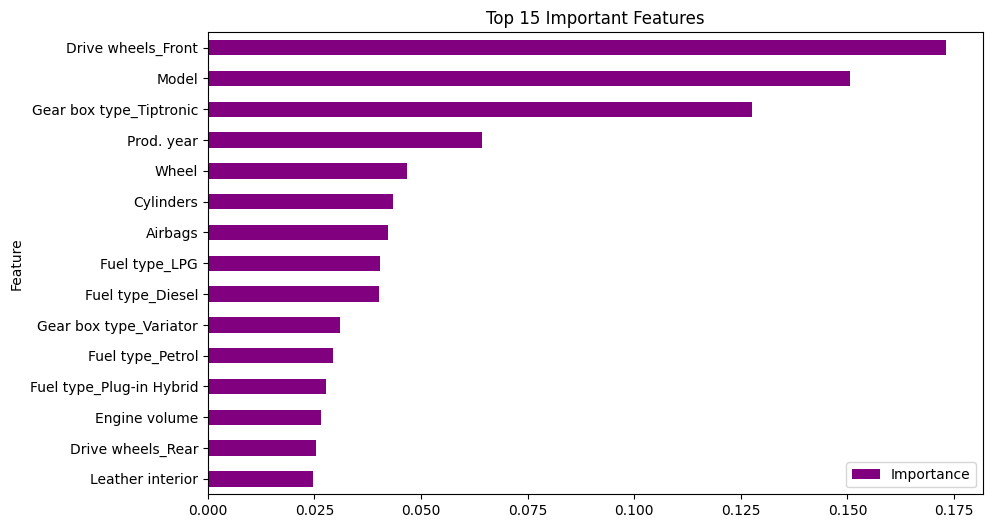

In [84]:
importances = best_model.feature_importances_
feat_names = X_train.columns

feat_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances})
feat_df.sort_values(by='Importance', ascending=False).head(15).plot(
    x='Feature', y='Importance', kind='barh', figsize=(10, 6), color='purple'
)
plt.title("Top 15 Important Features")
plt.gca().invert_yaxis()
plt.show()

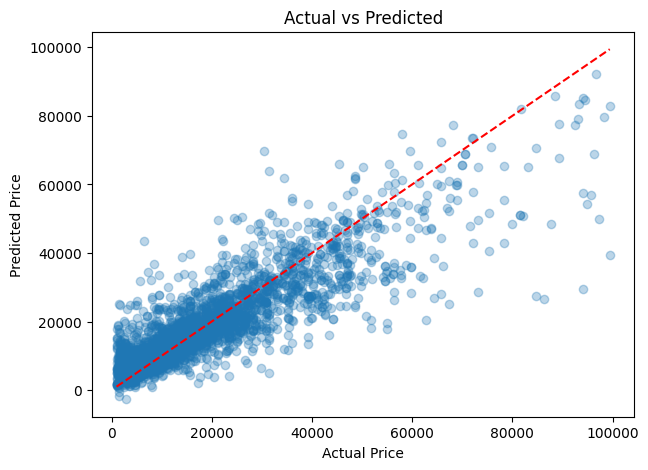

In [85]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='red')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()